# Project TransferLearning ResNet18 SealSealion


---

In [ ]:
import time
import os
import copy

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
# 8.2

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('device:', device)

device: cpu


### Hyperparameters
---

In [ ]:
# 8.3 하이퍼파라미터

num_epochs = 30
num_classes = 2
batch_size = 4
learning_rate = 0.001

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load dataset
---

In [ ]:
# 8.5

# Training을 위한 데이터 확장과 데이터셋 정규화

train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),  # 랜덤 리사이즈 후 크롭
        transforms.RandomHorizontalFlip(),  # 좌우반전
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

# Test를 위해서는 데이터셋 정규화만

test_transforms = transforms.Compose([
        transforms.Resize(256),             # 리사이즈
        transforms.CenterCrop(224),         # 가운데 크롭
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


In [ ]:
# 8.6

# ImageFolder를 사용하여 폴더 안에 있는 이미지들을 데이터셋으로 사용

train_dataset = datasets.ImageFolder( '/content/drive/MyDrive/seal_sealion_dataset/train', train_transforms)
test_dataset = datasets.ImageFolder( '/content/drive/MyDrive/seal_sealion_dataset/test', test_transforms)

train_loader = DataLoader( train_dataset, batch_size=batch_size, shuffle=True )
test_loader = DataLoader( test_dataset, batch_size=batch_size, shuffle=True )

# 분류 클래스 2개: ants, bees

class_names = train_dataset.classes
print(class_names)


['seal', 'sealion']


### Preview data

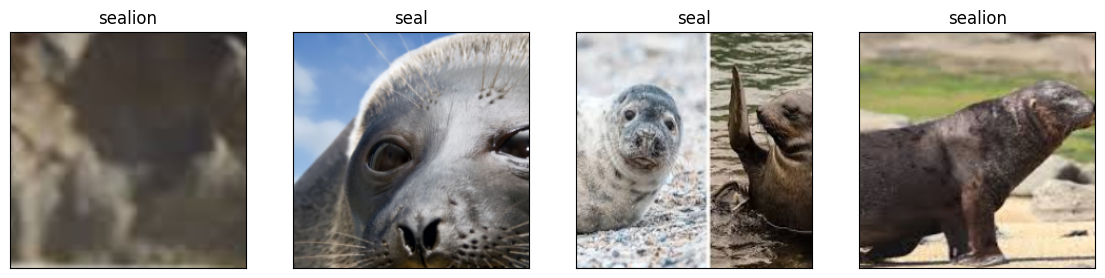

In [ ]:
# 8.7 데이터 미리보기

def convert_to_imshow_format(image):
    # from 3 x Height x Width to Height x Width x 3
    image = image.numpy().transpose(1,2,0)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # convert back to [0,1] range from [-1,1] range
    image = image * std + mean
    image = np.clip(image, 0, 1)

    return image

dataiter = iter(train_loader)
# images, labels = dataiter.next() # wrong
images, labels = next( dataiter )
images, labels = images[:6], labels[:6]

fig, axes = plt.subplots(1, len(images), figsize=(14,4))
for idx, image in enumerate(images):
    axes[idx].imshow(convert_to_imshow_format(image))
    axes[idx].set_title(class_names[labels[idx]])
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

### Progress monitor
---

In [ ]:
# 8.8

from IPython.display import HTML, display

# Custom IPython progress bar for training
class ProgressMonitor(object):

    tmpl = """
        <table style="width: 100%;">
            <tbody>
                <tr>
                    <td style="width: 30%;">
                     <b>Epoch: {epoch}/{num_epochs} Loss: {loss:0.4f}</b> &nbsp&nbsp&nbsp {value} / {length}
                    </td>
                    <td style="width: 70%;">
                        <progress value='{value}' max='{length}', style='width: 100%'>{value}</progress>
                    </td>
                </tr>
            </tbody>
        </table>
        """

    def __init__(self, length):
        self.length = length
        self.count = 0
        self.display = display(self.html(0, 0, 0, 0), display_id=True)

    def html(self, count, loss, epoch, num_epochs):
        return HTML(self.tmpl.format(length=self.length, value=count, loss=loss, epoch=epoch, num_epochs=num_epochs))

    def update(self, epoch, num_epochs, count, loss):
        self.count += count
        self.display.update(self.html(self.count, loss, epoch, num_epochs))

### Finetuning the convnet
___

In [ ]:
# Resnet18 구조 출력
model_ft = models.resnet18(pretrained=True)

print(model_ft)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 8.9 Finetuning the ConvNet

# 미리 훈련된 Resnet18 가져와서
model_ft = models.resnet18(pretrained=True)

# 마지막 fc layer 새로 만들어 out_features를 2로 변경
model_ft.fc = nn.Linear(model_ft.fc.in_features, 2)

# 모델을 cuda로 이동
model_ft = model_ft.to(device)

# Cross entropy loss 사용
loss_func = nn.CrossEntropyLoss()

# SGD
optimizer_ft = optim.SGD( model_ft.parameters(), lr=0.001, momentum=0.9 )

# 매 7 epochs 마다 학습률에 0.1을 곱함
lr_scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)



In [ ]:
# 8.10 ConvNet as Fixed feature extractor

# 미리 훈련된 Resnet18 가져와서
model_ft = models.resnet18(pretrained=True)

# 가중치 학습되지 않도록 전부 고정***
for param in model_ft.parameters():
    param.requires_grad = False

# 마지막 fc layer 새로 만들어 out_features를 2로 변경
model_ft.fc = nn.Linear(model_ft.fc.in_features, 2)

# 모델을 cuda로 이동
model_ft = model_ft.to(device)

# Cross entropy loss 사용
loss_func = nn.CrossEntropyLoss()

# SGD
optimizer_ft = optim.SGD( model_ft.parameters(), lr=0.001, momentum=0.9 )

# 매 7 epochs 마다 학습률에 0.1을 곱함
lr_scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


### Train
---

In [ ]:
# 8.11 Train

def train(epoch, num_epochs, model, optimizer, scheduler):

    # train phase
    model.train()

    # create a progress bar
    batch_loss_list = []
    progress = ProgressMonitor(length=len(train_dataset))

    for batch, target in train_loader:
        # Move the training data to the GPU
        batch, target = batch.to(device), target.to(device)

        # forward propagation
        output = model( batch )

        # calculate the loss
        loss = loss_func( output, target )

        # clear previous gradient computation
        optimizer.zero_grad()

        # backpropagate to compute gradients
        loss.backward()

        # update model weights
        optimizer.step()

        # update progress bar
        batch_loss_list.append(loss.item())
        progress.update(epoch, num_epochs, batch.shape[0], sum(batch_loss_list)/len(batch_loss_list) )

    # 스케쥴러의 스텝을 증가 - 때가 되면 학습률 변경
    if scheduler:
        scheduler.step()



In [ ]:
# 8.12 Test

def test(model):
    # test phase
    model.eval()

    correct = 0

    # We don't need gradients for test, so wrap in
    # no_grad to save memory
    with torch.no_grad():
        for batch, target in test_loader:
            # Move the training batch to the GPU
            batch, target = batch.to(device), target.to(device)

            # forward propagation
            output = model( batch )

            # get prediction
            output = torch.argmax(output, 1)

            # accumulate correct number
            correct += (output == target).sum().item()

    # Calculate test accuracy
    acc = 100 * float(correct) / len(test_dataset)
    print( 'Test Acc: {}/{} ({:.2f}%)'.format( correct, len(test_dataset), acc ) )

    return acc

In [ ]:
# 8.13

since = time.time()

# initialize the best weights
best_model_weights = copy.deepcopy( model_ft.state_dict() )
best_acc = 0.0

for epoch in range(num_epochs):

    # train
    train(epoch+1, num_epochs, model_ft, optimizer_ft, lr_scheduler_ft )
    # test
    acc = test(model_ft)

    # update the best weights
    if acc > best_acc:
        best_acc = acc
        best_model_weights = copy.deepcopy( model_ft.state_dict() )

# load the best weights
model_ft.load_state_dict( best_model_weights )

# summary
time_elapsed = time.time() - since
print('Training completed in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
print('Best test accuracy: {:4f}'.format(best_acc))



Epoch: 1/30 Loss: 0.7219 206 / 206,206


Test Acc: 76/92 (82.61%)


Epoch: 2/30 Loss: 0.5648 206 / 206,206


Test Acc: 77/92 (83.70%)


Epoch: 3/30 Loss: 0.6518 206 / 206,206


...

Test Acc: 89/92 (96.74%)


Epoch: 29/30 Loss: 0.4113 206 / 206,206


Test Acc: 82/92 (89.13%)


Epoch: 30/30 Loss: 0.4399 206 / 206,206


Test Acc: 84/92 (91.30%)
Training completed in 18m 41s
Best test accuracy: 96.739130


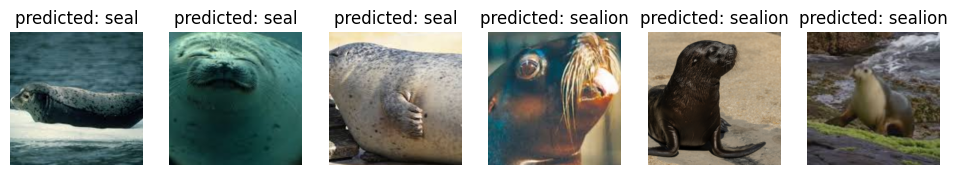

In [ ]:
# 8.14

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(12,12))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(1, num_images, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                ax.imshow( convert_to_imshow_format(inputs.cpu().data[j]) )

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)



visualize_model(model_ft)